In [1]:
# Web/Text Mining & Sentiment Analysis
## Wikipedia: The Legend of Zelda
# URL: https://en.wikipedia.org/wiki/The_Legend_of_Zelda

In [2]:
## 1. Import Libraries

In [3]:
import sys
!{sys.executable} -m pip install requests beautifulsoup4 textblob matplotlib pandas nltk

In [4]:
import requests                          # Sends HTTP requests to fetch web pages
from bs4 import BeautifulSoup           # Parses HTML and XML documents
import pandas as pd                      # Data manipulation and display
import matplotlib.pyplot as plt          # Plotting and visualizations
from textblob import TextBlob            # TextBlob sentiment analysis
import nltk
from nltk.tokenize import sent_tokenize  # Sentence tokenization
from nltk.corpus import stopwords        # Common stopwords for word frequency
from collections import Counter          # Count word frequencies
import re                                # Regular expressions for text cleaning

nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print("All libraries imported successfully.")

All libraries imported successfully.


In [5]:
## 2. Fetch the Wikipedia Page

In [6]:
url = "https://en.wikipedia.org/wiki/The_Legend_of_Zelda"
headers = {
    "User-Agent": "Mozilla/5.0 (Educational Project; Student Research)"
}
response = requests.get(url, headers=headers)

print("Status Code:", response.status_code)  # should now be 200

Status Code: 200


In [7]:
## 3. Parse the HTML Content

In [8]:
soup = BeautifulSoup(response.content, "html.parser")
print("Soup parsed.")

Soup parsed.


In [9]:
## 4. Extract the Page Title

In [10]:
title = soup.find("h1").text
print("Page Title:", title)

Page Title: The Legend of Zelda


In [11]:
## 5. Extract the Introduction

In [12]:
intro = ""
content = soup.find("div", {"id": "mw-content-text"})
if content:
    for p in content.find_all("p"):
        text = p.text.strip()
        if len(text) > 100:
            intro = text
            break

print("Introduction length:", len(intro))
print("Introduction:\n", intro[:500])

Introduction length: 270
Introduction:
 The Legend of Zelda[a] is a video game series created by Japanese game designers Shigeru Miyamoto and Takashi Tezuka. It is primarily developed and published by Nintendo, but some installments and re-releases have been outsourced to Flagship, Grezzo, and Tantalus Media.


In [13]:
## 6. Extract the History Section (Concept and Production)

In [14]:
# The Zelda article's "History" equivalent is "Conception and production"
history_heading = soup.find("h2", {"id": "Conception_and_production"})

if history_heading:
    history_content = []
    
    # Walk up to the heading wrapper div if it exists (modern Wikipedia)
    start_node = history_heading.find_parent("div", class_="mw-heading") or history_heading
    
    next_sibling = start_node.find_next_sibling()
    while next_sibling:
        # Stop at the next h2 or h2 wrapper
        if next_sibling.name == "h2":
            break
        if next_sibling.name == "div" and "mw-heading2" in (next_sibling.get("class") or []):
            break
        if next_sibling.name == "p":
            history_content.append(next_sibling.get_text())
        next_sibling = next_sibling.find_next_sibling()
    
    print(f"History (Conception and Production) — {len(history_content)} paragraphs:\n")
    for paragraph in history_content:
        print(paragraph.strip())
        print()
else:
    print("Section not found.")

History (Conception and Production) — 6 paragraphs:

The Legend of Zelda was principally inspired by Shigeru Miyamoto's "explorations" as a young boy in the hillsides and forests surrounding his childhood home in Sonobe, Japan. According to Miyamoto, one of his most memorable experiences was finding a cave entrance in the middle of the woods.[88] After some hesitation, he entered the cave and explored its depths with the aid of a lantern. Miyamoto has referred to the creation of the Zelda games as an attempt to bring to life a "miniature garden" for players to play with in each game of the series.[89]

The story and setting were developed by Takashi Tezuka. Seeking to create a fairytale adventure game, Tezuka drew inspirations from fantasy books such as J. R. R. Tolkien's The Lord of the Rings.[90][91][92] According to Keiji Terui, who wrote the backstory in the first game's manual, the location named Death Mountain was initially a working title for the legend of the Triforce which was

In [15]:
## 7. Extract All Sections (Main Content)

In [16]:
# Extract the key sections of the page
sections = soup.find_all("h2")
for section in sections:
    section_title = section.text
    section_content_tag = section.find_next("p")
    if section_content_tag:
        section_content = section_content_tag.text
        print("Section Title:", section_title)
        print("Section Content:", section_content[:300])
        print()

Section Title: Contents
Section Content: 


Section Title: Gameplay
Section Content: Gameplay of The Legend of Zelda games feature a mix of puzzles, action-adventure, and exploration. These elements used to be constant[b] throughout the series, with small refinements and additions in each new game. Later installments include stealth gameplay, where the player must avoid enemies whil

Section Title: Conception and production
Section Content: The Legend of Zelda was principally inspired by Shigeru Miyamoto's "explorations" as a young boy in the hillsides and forests surrounding his childhood home in Sonobe, Japan. According to Miyamoto, one of his most memorable experiences was finding a cave entrance in the middle of the woods.[88] Afte

Section Title: Plot
Section Content: The Legend of Zelda takes place predominantly in a medieval Western Europe-inspired fantasy world called Hyrule,[110][111] which has developed a deep history and wide geography over the series's many releases. Hyrule

In [17]:
## 8. Extract External Links (References)

In [18]:
# Extract the external links
external_links = soup.find_all("a", {"class": "external text"})
print("External Links (References):")
for link in external_links[:15]:  # show first 15
    print(link.get("href"))

External Links (References):
https://www.google.com/search?as_eq=wikipedia&q=%22The+Legend+of+Zelda%22
https://www.google.com/search?tbm=nws&q=%22The+Legend+of+Zelda%22+-wikipedia&tbs=ar:1
https://www.google.com/search?&q=%22The+Legend+of+Zelda%22&tbs=bkt:s&tbm=bks
https://www.google.com/search?tbs=bks:1&q=%22The+Legend+of+Zelda%22+-wikipedia
https://scholar.google.com/scholar?q=%22The+Legend+of+Zelda%22
https://www.jstor.org/action/doBasicSearch?Query=%22The+Legend+of+Zelda%22&acc=on&wc=on
https://en.wikipedia.org/w/index.php?title=Talk%3AThe_Legend_of_Zelda&preload=Template%3ASubmit+an+edit+request%2Fpreload&action=edit&section=new&editintro=Template%3AEdit+fully-protected%2Feditintro&preloadtitle=Protected+edit+request+on+3+May+2026&preloadparams%5B%5D=edit+fully-protected&preloadparams%5B%5D=The+Legend+of+Zelda
https://en.wikipedia.org/w/index.php?title=The_Legend_of_Zelda&action=edit&section=
https://en.wikipedia.org/w/index.php?title=The_Legend_of_Zelda&action=edit
https://en.wik

In [19]:
## 9. Collect Full Text Per Section for Sentiment Analysis

In [20]:
def clean_text(text):
    """Remove citation numbers like [1] and extra whitespace."""
    text = re.sub(r"\[\d+\]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Build full text for each section - use mw-content-text which is more stable
content_div = soup.find("div", {"id": "mw-content-text"})
all_paragraphs = content_div.find_all("p")
main_content_text = " ".join(
    p.get_text() for p in all_paragraphs if len(p.get_text(strip=True)) > 50
)

# Combine the history paragraphs we collected earlier
history_text = " ".join(history_content) if history_heading else "Not found"

section_texts = {
    "Title":                  title,
    "Introduction":           clean_text(intro),
    "History":                clean_text(history_text),
    "Main Content":           clean_text(main_content_text),
    "References (ext links)": " ".join(link.get("href") for link in external_links[:15])
}

for name, text in section_texts.items():
    print(f"{name}: {len(text.split())} words")

Title: 4 words
Introduction: 41 words
History: 527 words
Main Content: 10123 words
References (ext links): 15 words


In [21]:
## 10. Sentiment Analysis — TextBlob

## **TextBlob** is an NLP library that performs sentiment analysis by examining words and phrases and returning two scores:
## **Polarity**: ranges from –1.0 (very negative) to +1.0 (very positive)
## **Subjectivity**: ranges from 0.0 (fully objective/factual) to 1.0 (fully subjective/opinion-based)

In [22]:
def textblob_sentiment(text):
    blob = TextBlob(text)
    polarity     = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    if polarity > 0.05:
        label = "Positive"
    elif polarity < -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    return round(polarity, 4), round(subjectivity, 4), label

results = []
for section_name, text in section_texts.items():
    pol, sub, label = textblob_sentiment(text)
    results.append({
        "Section":      section_name,
        "Polarity":     pol,
        "Subjectivity": sub,
        "Sentiment":    label
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

               Section  Polarity  Subjectivity Sentiment
                 Title    0.0000        0.0000   Neutral
          Introduction   -0.1750        0.2750  Negative
               History   -0.0398        0.3146   Neutral
          Main Content    0.0289        0.4097   Neutral
References (ext links)    0.0000        0.0000   Neutral


In [23]:
## 11. Visualizations

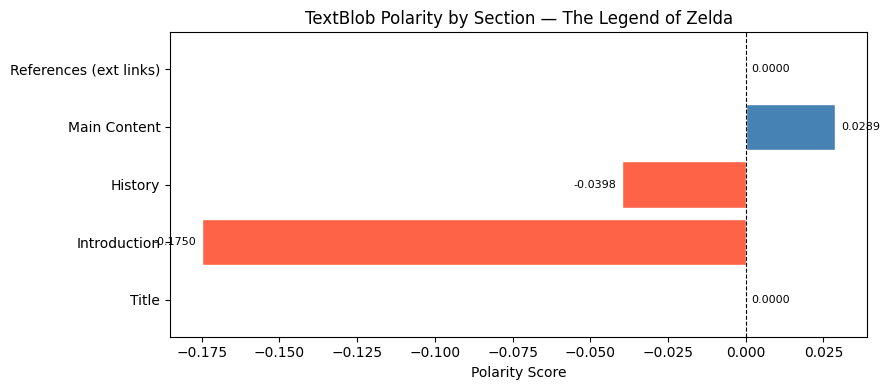

In [24]:
# --- Plot 1: Polarity by Section ---
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["steelblue" if p >= 0 else "tomato" for p in results_df["Polarity"]]
bars = ax.barh(results_df["Section"], results_df["Polarity"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Polarity Score")
ax.set_title("TextBlob Polarity by Section — The Legend of Zelda")
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=8)
plt.tight_layout()
plt.savefig("polarity_by_section.png", dpi=150)
plt.show()

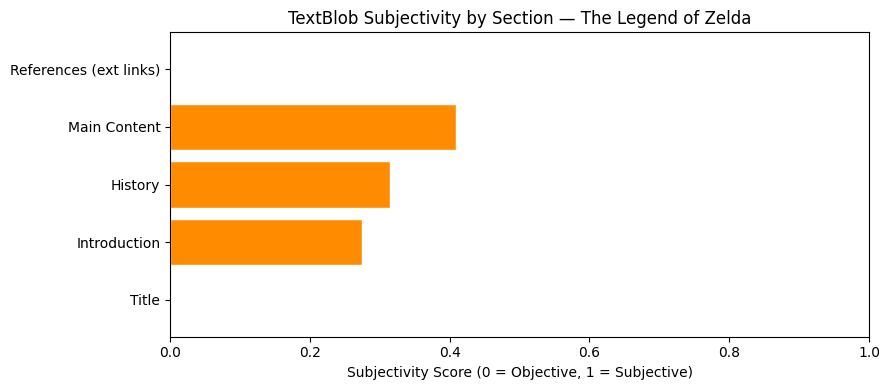

In [25]:
# --- Plot 2: Subjectivity by Section ---
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(results_df["Section"], results_df["Subjectivity"], color="darkorange", edgecolor="white")
ax.set_xlabel("Subjectivity Score (0 = Objective, 1 = Subjective)")
ax.set_title("TextBlob Subjectivity by Section — The Legend of Zelda")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("subjectivity_by_section.png", dpi=150)
plt.show()

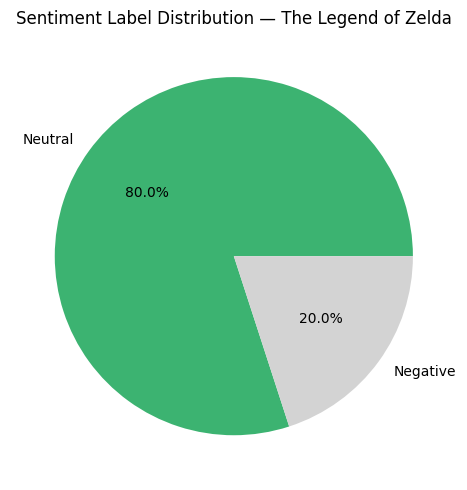

In [26]:
# --- Plot 3: Sentiment Label Distribution (Pie Chart) ---
label_counts = results_df["Sentiment"].value_counts()
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(label_counts, labels=label_counts.index, autopct="%1.1f%%",
       colors=["mediumseagreen", "lightgray", "tomato"][:len(label_counts)])
ax.set_title("Sentiment Label Distribution — The Legend of Zelda")
plt.tight_layout()
plt.savefig("sentiment_distribution.png", dpi=150)
plt.show()

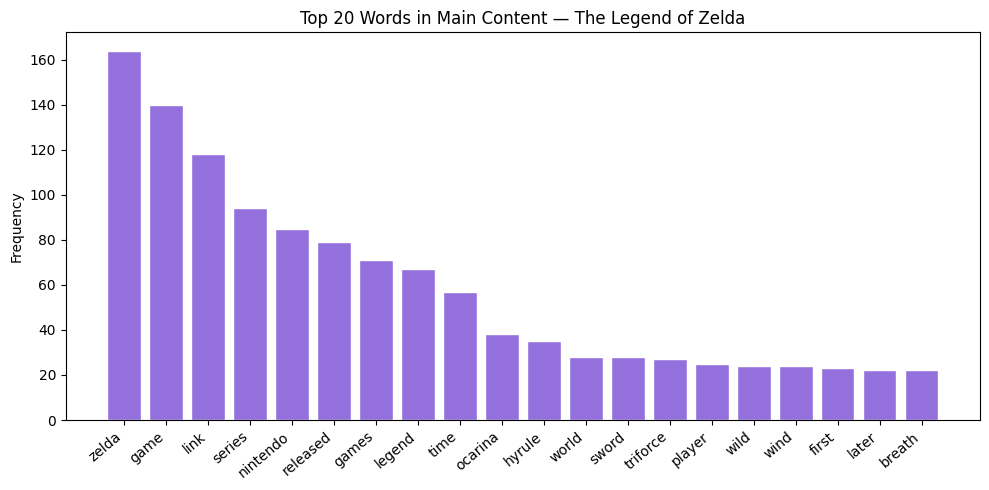

In [27]:
# --- Plot 4: Top 20 Most Frequent Words in Main Content ---
stop_words = set(stopwords.words("english"))
words = [
    w.lower() for w in re.findall(r"\b[a-zA-Z]{4,}\b", section_texts["Main Content"])
    if w.lower() not in stop_words
]
word_freq = Counter(words).most_common(20)
words_list, counts = zip(*word_freq)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(words_list, counts, color="mediumpurple", edgecolor="white")
ax.set_ylabel("Frequency")
ax.set_title("Top 20 Words in Main Content — The Legend of Zelda")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("word_frequency.png", dpi=150)
plt.show()

In [28]:
sentences = sent_tokenize(section_texts["Introduction"])

sent_rows = []
for i, sent in enumerate(sentences):
    pol, sub, label = textblob_sentiment(sent)
    sent_rows.append({
        "#":           i + 1,
        "Sentence":    sent[:65] + "...",
        "Polarity":    pol,
        "Subjectivity": sub,
        "Sentiment":   label
    })

sent_df = pd.DataFrame(sent_rows)
print(sent_df.to_string(index=False))

 #                                                             Sentence  Polarity  Subjectivity Sentiment
 1 The Legend of Zelda[a] is a video game series created by Japanese...   -0.2667        0.2667  Negative
 2 It is primarily developed and published by Nintendo, but some ins...    0.1000        0.3000  Positive
